## Implementación Algoritmos de Optimziación
-  Autor: Germán Homero Morán Figueroa
- Descripción: Este notebook se realiza la implementación de los algortimos de optimización:
    - HC: Hill Climbing
    - SA: Simuling Aneling
    - GWO: Grey Wolf Optimier


- Salida: Practicas de manejo agricolas optimizadas, curvas de comparación del desempeño de los algorimos heuristicos

In [1]:
#  Librerias y Dependencias
# =======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import random
import joblib

In [35]:
'''
  Función para Graficar curva de convergencia individual
'''
def plot_convergence_curve(fitness_history, alg):
  efos = np.arange(len(fitness_history))
  plt.title("Convergence curve")
  plt.xlabel("EFOs")
  plt.ylabel("Fitness (Yield[Kg/Ha])")
  plt.plot(efos, fitness_history, label= str(alg))
  plt.legend()
  #plt.savefig("Convergence curve for " + str(f) + "" + str(alg) + ".png")
  plt.show()


'''
  Función para graficar curva de convergencia entre diferentes algortimos
'''

def plot_convergence_curve_comparison(fitness_history, alg):
  efos = np.arange(len(fitness_history[0]))
  plt.title("Convergence curve for HC, SA y GWO")
  plt.xlabel("EFOs")
  plt.ylabel("Fitness")
  algorithms = len(alg)
  for a in range(algorithms):
    plt.plot(efos, fitness_history[a], label=str(alg[a]))
  plt.legend()
  #plt.savefig("Convergence curve for " + str(f) + "" + str(alg) + ".png")
  plt.show()

def print_alorithms_with_avg_fitness(alg, avg_fitness):
  rows = len(alg)
  for r in range(rows):
    print(alg[r] + " {0:12.6f}".format(avg_fitness[r]))

In [18]:
'''
    Esta clase permite realizar la codificación onehot especificamente para variables categoricas
'''
class OneHotCoding():
    def __init__(self, df, bin_features):
        self.bin_features = bin_features
        self.df = df

    # Metodo para realizar la codificacion dummy a las variables categoricas

    def dummyCodification(self):
        cat_features = self.df.select_dtypes(include = ["object", "category"]).columns
        bin_dataset = self.df[self.bin_features].replace({'SI': 1, 'NO': 0})
        categorical_features = [x for x in cat_features if x not in self.bin_features]
        df_cat = pd.get_dummies(self.df[categorical_features])
        self.df.drop(cat_features, axis = 1, inplace = True)
        df_final = pd.concat([self.df,df_cat,bin_dataset ], axis = 1)
        #df_final.to_csv("daset_codificado.csv")
        print("Ejeción Terminada")
        return df_final, categorical_features

'''
    Esta es la función Objetivo a maximizar (Prediccion Generada Algortimo ClR)
'''

class CLR():
  def __init__(self, modelo_clasificacion, modelo_regresion):
        self.modelo_clasificacion = modelo_clasificacion
        self.modelo_regresion = modelo_regresion

  def etapaClasficacion(self):
    grupo_asignado = self.modelo_clasificacion.predict(self.registro)
    return grupo_asignado[0]

  def etapaRegresion(self, ga):
    prediccion = self.modelo_regresion[ga].predict(self.registro.values)
    return prediccion[0]

  def evaluate(self,registro):
    grupo_asignado = self.modelo_clasificacion.predict(registro)[0]
    prediccion = self.modelo_regresion[grupo_asignado].predict(registro.values)
    return prediccion[0]





'''
    Esta clase nos permite generar los siguientes objetos:
    - Solución Inicial  donde nos retorna el rendimeitno, fiteness (Ganancia) y costo
    - Solucion modificada Tweck Update deacuerdo rango de Variables de Optimización
         - Para variables contiuas se agrega una pequeña modificación o twick dentro de los limites
         - Para variables categoricas se selecciona un valor diferente al actual en el registro
         - Al final del metodo twick update nos retorna el rendimeitno, fiteness (Ganancia) y costo
'''

class Solution():
  def __init__(self, variablesOptimizar, f,f_cost, reg_opt, col_train_model,cf, presupuesto, precioVenta):
    self.variablesOptimizar = variablesOptimizar
    self.cf = cf
    self.function = f
    self.fitness = 0
    self.reg_opt = reg_opt
    self.col_train_model = col_train_model
    self.f_cost = f_cost
    self.presupuesto = presupuesto
    self.precioVenta = precioVenta



  def initialization(self):
    df_opt= self.reg_opt.copy()
    df_opt_dm = pd.get_dummies(df_opt, columns=self.cf,dtype=np.int64)
    df_opt_dm_m = df_opt_dm.reindex(columns=self.col_train_model, fill_value=0)
    print(df_opt_dm.shape)
    self.fitness= self.function.evaluate(df_opt_dm_m)

  # Calculamos costo y ganacia de la solución inicial
    self.costo = self.f_cost.evaluate(df_opt)
    # Aqui se define el presupuesto asociado para mi LOTE.
    if self.costo < self.presupuesto:
      self.Ganancia = (self.fitness * self.precioVenta) - self.costo
    else:
      self.Ganancia = float('-inf')

    return self.fitness, df_opt, df_opt_dm_m, np.round(self.Ganancia,2), np.round(self.costo,2)

  def twekUpdate(self,bandwidth):
    dff= self.reg_opt.copy()
    #Proceso twick [variables categoricas y continuas]
    #========================================================================
    bandwidths = np.random.uniform(low=-bandwidth, high=bandwidth)
    var_select = list(np.random.choice(self.variablesOptimizar, 3, replace=False))
    list_vac = []
    for variable in var_select:
        match variable:
            case 'ContEnfQui_Emer_Flor':
              r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContEnfQui_Flor_Cose':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContMalMec_Siem_Emer':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContMalMec_Emer_Flor':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContMalMec_Flor_Cose':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContMalQui_Antes_Siem':
              r = np.random.choice([x for x in range(3) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContMalQui_Siem_Emer':
              r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContMalQui_Emer_Flor':
              r = np.random.choice([x for x in range(5) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContMalQui_Flor_Cose':
              r = np.random.choice([x for x in range(2) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContPlaQui_Antes_Siem':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContPlaQui_Siem_Emer':
              r = np.random.choice([x for x in range(3) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContPlaQui_Emer_Flor':
              r = np.random.choice([x for x in range(10) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContPlaQui_Flor_Cose':
              r = np.random.choice([x for x in range(3) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'TotN_Antes_Siem':
              valor = dff[variable].values[0] + bandwidths
              valor = round(np.clip(valor, 0, 105),2)
              list_vac.append(valor)

            case 'TotN_Siem_Emer':
              valor = dff[variable].values[0] + bandwidths
              valor = round(np.clip(valor, 0, 82.5),2)
              list_vac.append(valor)

            case 'TotN_Emer_Flor':
              valor = dff[variable].values[0] + bandwidths
              valor = round(np.clip(valor, 0, 276),2)
              list_vac.append(valor)

            case 'TotP_Antes_Siem':
              valor = dff[variable].values[0] + bandwidths
              valor = round(np.clip(valor, 0, 24),2)
              list_vac.append(valor)

            case 'TotP_Siem_Emer':
              valor = dff[variable].values[0] + bandwidths
              valor = round(np.clip(valor, 0, 40),2)
              list_vac.append(valor)

            case 'TotP_Emer_Flor':
              valor = dff[variable].values[0] + bandwidths
              valor = round(np.clip(valor, 0, 47.5),2)
              list_vac.append(valor)

            case 'TotK_Antes_Siem':
              valor = dff[variable].values[0] + bandwidths
              valor = round(np.clip(valor, 0, 30),2)
              list_vac.append(valor)

            case 'TotK_Siem_Emer':
              valor = dff[variable].values[0] + bandwidths
              valor = round(np.clip(valor, 0, 75),2)
              list_vac.append(valor)

            case 'TotK_Emer_Flor':
              valor = dff[variable].values[0] + bandwidths
              valor = round(np.clip(valor, 0, 180),2)
              list_vac.append(valor)

            case 'FerOrg_Emer_Flor':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'FerQui_Antes_Siem':
              r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'FerQui_Siem_Emer':
              r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'FerQui_Emer_Flor':
              r = np.random.choice([x for x in range(8) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)


            case _:
                print("Error")

    # Actualizacion Registro a Optimizar
    # =====================================================================================
    #print("Valore var_ selected: ", list_vac)
    dff.loc[:,var_select]= list_vac
    nrd = pd.get_dummies(dff, columns=self.cf,dtype=np.int64)
    nrd_m = nrd.reindex(columns=self.col_train_model, fill_value=0)
    self.fitness= self.function.evaluate(nrd_m)

    # Calculo de la ganacia y costo asociado al registro

    self.costo = self.f_cost.evaluate(dff)
    # Aqui se define el presupuesto asociado para mi LOTE.
    if self.costo < self.presupuesto:
      self.Ganancia = (self.fitness * self.precioVenta) - self.costo
    else:
      self.Ganancia = float('-inf')

    return self.fitness, dff, nrd_m, np.round(self.Ganancia,2), np.round(self.costo,2)

  def calculateGanancia(self, reg_opt):
    self.Ganancia = (self.fitness * self.precioVenta) -(self.f_cost.evaluate(reg_opt))
    return np.round(self.Ganancia,2)

'''
  Heuristica Inicial: Hill Climbing
'''
class HC:
    def __init__(self, max_efos: int, bandwidth):
        self.max_efos = max_efos
        self.bandwidth = bandwidth

    def evolve(self,variablesOptimizar, f1,fc, df_opti, columns_train_models,cf, presupuesto, precioVenta):
        no_improvement_count = 0
        best_fitness_history = np.zeros(self.max_efos, float)
        Sol = Solution(variablesOptimizar, f1,fc,df_opti, columns_train_models,cf, presupuesto,precioVenta)
        Qs, S, S_d, gan, cos = Sol.initialization()
        Qsg = gan
        best_fitness_history[0] = Qsg
        for iteration in range(1, self.max_efos):
            Sol1 = Solution(variablesOptimizar, f1,fc, S, columns_train_models,cf, presupuesto,precioVenta)
            Qr, R, R_d, Qrg, Qcc = Sol1.twekUpdate(self.bandwidth)
            if (Qrg > Qsg):
              Qsg = Qrg
              S = R
              no_improvement_count = 0
            else:
              no_improvement_count += 1
              if no_improvement_count >= 50:
                best_fitness_history[iteration:] = Qsg
                break
            best_fitness_history[iteration] = Qsg

        # Retorno el historial, la mejor ganancia y la mejor solucion.
        return best_fitness_history, Qsg, S

    def __str__(self):
        result = "Hill-Climbing"
        return result


'''
Heuristica SA: Simuling Anneling
'''

class SA:
    def __init__(self, max_efos, bandwidth):
        self.max_efos = max_efos
        self.bandwidth = bandwidth

    def evolve(self,variablesOptimizar, f1, fc,  df_opti, columns_train_models,cf,presupuesto, precioVenta):
        no_improvement_count = 0
        to = 100
        best_fitness_history = np.zeros(self.max_efos, float)
        # [Sol es  inicialmente, el registro Original]
        Sol = Solution(variablesOptimizar, f1,fc,df_opti, columns_train_models,cf, presupuesto,precioVenta)
        Qs, s, S_d, Qsg, Qscos = Sol.initialization()
        best_fitness_history[0] = Qsg

        # Best  (El best Inicial el (Ganancia Inicial))
        # =============
        qbest = Qsg
        best = s.copy()
        # =============
        t= to
        for iteration in range(1, self.max_efos):
            Sol1 = Solution(variablesOptimizar, f1, fc, s, columns_train_models,cf, presupuesto, precioVenta)
            Qr, R, R_d, Qrg, Qcc = Sol1.twekUpdate(self.bandwidth)
            #print(f"Calidad R: {Qr} y Ganacia  de R {Qrg} y Costo Asociado Solucion es : {Qcc}")
            #print("Calidad R: ", Qr)
            t = t - to/(self.max_efos + 1)
            #print("Temperatura asociada: ", t)
            ale = np.random.uniform()
            prob = np.exp((Qrg-Qsg) / t) # Maximizando (Ganancias)
            #print(f"El numero aletorio es: {ale} y la probabilida  es  {prob}")
            if Qrg > Qsg or ale < prob:
                Qsg = Qrg
                s = R

            if Qsg > qbest:
                best = s
                qbest = Qsg
                no_improvement_count = 0
            else:
                no_improvement_count += 1
                if no_improvement_count >= 50:
                  best_fitness_history[iteration:] = Qsg
                  break

            best_fitness_history[iteration] = qbest

        return best_fitness_history, qbest,best

    def __str__(self):
        result = "SA"
        return result


'''
  Funcion de Costos - Calculo costos Optimizar
'''
class CostVariables():
    def __init__(self, lista_costos_unitarios, variables_optimizar):
      self.lista_costos_unitarios = lista_costos_unitarios
      self.variables_optimizar = variables_optimizar

    def evaluate(self, reg_opt):
      cost_reg_opt = reg_opt[self.variables_optimizar] *(self.lista_costos_unitarios)
      a = np.round(cost_reg_opt.values[0].sum(),2)
      return a



In [69]:
#1. Cargue de los conjuntos de datos
#===============================================================================================================
df_original = pd.read_csv("DatasetFinal.csv")
df =  df_original.copy()

df_target = df.RDT_AJUSTADO
df_features = df.drop(["RDT_AJUSTADO", "ID_LOTE"], axis=1)
print("Longitud Dataset Total: ", df.shape)
df.head(5)

#2. Codificación de variables categoricas - Dummy (variables Binarias  0-1)
# =====================================================================================================================
bin_features =['SEM_TRATADAS','DRENAJE','ALMACENAMIENTO_FINCA','CAP_ENDURE_RASTA','MOTEADOS_RASTA','MOTEADOS_MAS70cm._RASTA',
               'OBSERVA_EROSION_RASTA','OBSERVA_MOHO_RASTA','OBSERVA_RAICES_VIVAS_RASTA','OBSERVA_HOJARASCA_MO_RASTA',
                'SUELO_NEGRO_BLANDO_RASTA','CUCHILLO_PRIMER_HTE_RASTA','CERCA_RIOS_QUEBRADAS_RASTA',
               ]


df_features[bin_features] = df_features[bin_features].replace({'SI': 1, 'NO': 0})


Longitud Dataset Total:  (799, 116)


<ipython-input-69-020f8119afe0>:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_features[bin_features] = df_features[bin_features].replace({'SI': 1, 'NO': 0})


In [37]:
# Verificación del dataframe
df_features

,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,PH_RASTA,PEDREG_PERFIL_ROCAS,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,d.interno,drenaje_externo,Porc_A,Porc_Ar,Porc_ArA,Porc_ArL,Porc_FrL,Porc_L,Porc_F,porc.x,porc.y,Porc_AF,Porc_BLANDO,Porc_DURO,Porc_EXT_DURO,Porc_FRIABLE,Porc_FIRME,Porc_EXT_FIRME,Porc_PLASTICO,Porc_MUY_PLASTICO,Temp_Max_Avg_Veg,Temp_Min_Avg_Veg,Temp_Avg_Veg,Diurnal_Range_Avg_Veg,Sol_Ener_Accu_Veg,Temp_Max_34_Freq_Veg,Rain_Accu_Veg,Rain_10_Freq_Veg,Rhum_Avg_Veg,Temp_Max_Avg_For,Temp_Min_Avg_For,Temp_Avg_For,Diurnal_Range_Avg_For,Sol_Ener_Accu_For,Temp_Max_34_Freq_For,Rain_Accu_For,Rain_10_Freq_For,Rhum_Avg_For,Temp_Max_Avg_Mad,Temp_Min_Avg_Mad,Temp_Avg_Mad,Diurnal_Range_Avg_Mad,Sol_Ener_Accu_Mad,Temp_Max_34_Freq_Mad,Rain_Accu_Mad,Rain_10_Freq_Mad,Rhum_Avg_Mad
0,Manual,0,Otro,Algodon,1,Manual,1,5,46,74,73000,18,0,0,0,0,0,0,1,0,0,0,1,5,0,0.0,0.0,57.5,0,0.0,0.0,0,0.0,0.0,0,0,0,1,4.0,PLANO O LLANO,PLANO,2,6.0,SIN ROCAS,0,-1,-1.0,0,-1,0,GRANULAR,0,0,NO HAY,LA MANIANA Y LA TARDE,NO HAY,NO HAY,NO,1,34,PLANTAS NORMALES,0,0,1,0,ESPACIADO,60,BUENO,LENTO,0,0.00,0.0,0.0,0.00,0.00,0.0,61.67,38.33,0.0,0.0,0.0,0.0,100.00,0.00,0.0,0.00,0.0,33.83,24.73,29.28,9.10,15505.82,0.42,118.3,0.08,79.27,33.99,24.42,29.20,9.57,22471.86,0.48,306.2,0.19,80.25,33.41,24.48,28.94,8.94,10617.20,0.36,54.8,0.07,82.21
1,Mecanizado,1,P3966 (Pioneer),Algodon,1,Manual,1,5,45,98,60000,10,0,0,0,0,0,0,0,0,1,0,0,0,1,0.0,0.0,92.0,0,0.0,0.0,0,0.0,90.0,0,0,0,3,1.0,PLANO O LLANO,PLANO,2,5.0,SIN ROCAS,0,-1,-1.0,0,-1,0,ATERRONADA,0,0,POCO MARCADAS,LA MANIANA Y LA TARDE,NO HAY,NO HAY,NO,1,35,PLANTAS NORMALES,0,0,1,1,MUY BUENO,60,BUENO,NINGUNO,0,0.00,0.0,0.0,58.33,41.67,0.0,0.00,0.00,0.0,0.0,100.0,0.0,0.00,0.00,0.0,0.00,0.0,33.99,24.71,29.35,9.28,15239.28,0.60,189.1,0.15,79.50,34.26,24.68,29.47,9.59,22480.59,0.50,253.4,0.14,78.98,33.72,24.51,29.12,9.21,19483.40,0.43,142.1,0.12,81.22
2,Mecanizado,0,P4082 (Pioneer),Algodon,1,Manual,1,5,48,78,72000,17,0,0,0,0,0,0,1,1,0,0,0,2,0,0.0,0.0,92.0,0,0.0,0.0,0,0.0,60.0,0,0,0,4,4.0,PLANO O LLANO,PLANO,2,5.5,SIN ROCAS,0,-1,-1.0,0,-1,0,GRANULAR,0,0,NO HAY,LA MANIANA Y LA TARDE,NO HAY,NO HAY,NO,1,24,PLANTAS NORMALES,0,0,1,0,ESPACIADO,60,BUENO,LENTO,0,0.00,0.0,0.0,0.00,0.00,0.0,100.00,0.00,0.0,0.0,0.0,0.0,100.00,0.00,0.0,0.00,0.0,33.22,24.32,28.77,8.90,14930.25,0.35,181.3,0.12,80.62,34.39,24.58,29.49,9.82,22703.70,0.55,272.6,0.16,79.30,33.34,24.47,28.91,8.87,12858.10,0.32,88.6,0.12,82.18
3,Mecanizado,1,Otro,Algodon,1,Manual,1,5,45,79,71000,18,0,0,0,0,0,0,2,0,0,0,0,2,0,0.0,0.0,92.0,0,0.0,0.0,0,0.0,30.0,0,0,0,3,5.0,PLANO O LLANO,PLANO,2,6.0,SIN ROCAS,0,-1,-1.0,0,-1,0,GRANULAR,0,0,NO HAY,LA MANIANA Y LA TARDE,NO HAY,NO HAY,NO,1,31,PLANTAS NORMALES,0,0,1,0,ESPACIADO,60,BUENO,LENTO,0,0.00,0.0,0.0,0.00,0.00,0.0,56.67,43.33,0.0,0.0

In [71]:
# Artefactos (Algortimo CLR - Best Model Logrado en entrenamiento)
# ===============================================================================
modelo_clasificacion = joblib.load('model_clasf.pkl')
modelo_reg1 = joblib.load('modelo_0.pkl')
modelo_reg2 = joblib.load('modelo_1.pkl')
lista_models= [modelo_reg1,modelo_reg2]

#============== Variables a Optimizar para lograr el mayor rendimiento=============
# Variables Fijas: Clima, Suelo,
# Variable Mejorar: Practicas de Manejo (22 varaibles)
# ================================================================================
variablesOptimizar=['ContEnfQui_Emer_Flor','ContEnfQui_Flor_Cose','ContMalMec_Siem_Emer','ContMalMec_Emer_Flor',
                    'ContMalMec_Flor_Cose','ContMalQui_Antes_Siem','ContMalQui_Siem_Emer','ContMalQui_Emer_Flor',
                    'ContMalQui_Flor_Cose','ContPlaQui_Antes_Siem','ContPlaQui_Siem_Emer','ContPlaQui_Emer_Flor',
                    'ContPlaQui_Flor_Cose','TotN_Antes_Siem','TotN_Siem_Emer','TotN_Emer_Flor','TotP_Antes_Siem',
                    'TotP_Siem_Emer','TotP_Emer_Flor','TotK_Antes_Siem','TotK_Siem_Emer','TotK_Emer_Flor']

print("Longitud variables Optimizar: ", len(variablesOptimizar))
# Definición de costos unitarios de c/d variable
# =====================================================
CostosUnitariosVarOpimizar = [35000,35000, 400000,400000,
                              400000,64000,64000, 35000,
                              64000, 80000,130000,130000,
                              130000,3200,3200,3200,4000,
                              4000, 4000,3000,3000,3000]

print("Longitud costos Unitarios: ", len(CostosUnitariosVarOpimizar))

# Variable categoricas Dumificar dentro DF
# ==================================================================
cf = ['TIPO_SIEMBRA','MATERIAL_GENETICO','CULT_ANT','METODO_COSECHA','TERRENO_CIRCUN_RASTA','POSICION_PERFIL_RASTA','PEDREG_PERFIL_ROCAS',
 'ESTRUCTURA_RASTA','OBSERVA_COSTRAS_DURAS_RASTA','SITIO_EXPUESTO_SOL_RASTA','OBSERVA_COSTRAS_BLANCAS_RASTA','OBSERVA_COSTAS_NEGRAS_RASTA',
 'REGION_SECA_ARIDA_RASTA','OBSERVA_PLANTAS_PEQUENAS_RASTA','RECUBRIMIENTO_VEGETAL__SUELO_RASTA','d.interno','drenaje_externo']

# Columnas (Esquema) Utilizado por los modelos para lograr Predicción
# Cada nuevo registro debe tener este esquema para poder realizar la predicción
# =============================================================================
columns_train_models = pd.read_csv("columns_train_model.csv")['0'].values

# Registro Optimizar (prueba 82-84)
# ==============================================================================
df_opti =df_features.loc[84:84,:]
df_opti


Longitud variables Optimizar:  22
Longitud costos Unitarios:  22


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ElasticNet from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,TIPO_SIEMBRA,SEM_TRATADAS,MATERIAL_GENETICO,CULT_ANT,DRENAJE,METODO_COSECHA,ALMACENAMIENTO_FINCA,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor,FerOrg_Emer_Flor,FerQui_Antes_Siem,FerQui_Siem_Emer,FerQui_Emer_Flor,PENDIENTE_RASTA,TERRENO_CIRCUN_RASTA,POSICION_PERFIL_RASTA,NO_CAPAS_RASTA,PH_RASTA,PEDREG_PERFIL_ROCAS,CAP_ENDURE_RASTA,PROFUND_CAP_ENDURE_RASTA,ESPESOR_CAP_ENDURE_RASTA,MOTEADOS_RASTA,PROFUND_MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,ESTRUCTURA_RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_COSTRAS_DURAS_RASTA,SITIO_EXPUESTO_SOL_RASTA,OBSERVA_COSTRAS_BLANCAS_RASTA,OBSERVA_COSTAS_NEGRAS_RASTA,REGION_SECA_ARIDA_RASTA,OBSERVA_RAICES_VIVAS_RASTA,PROFUND_RAICES_VIVAS_RASTA,OBSERVA_PLANTAS_PEQUENAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA,RECUBRIMIENTO_VEGETAL__SUELO_RASTA,prof_efectiva,d.interno,drenaje_externo,Porc_A,Porc_Ar,Porc_ArA,Porc_ArL,Porc_FrL,Porc_L,Porc_F,porc.x,porc.y,Porc_AF,Porc_BLANDO,Porc_DURO,Porc_EXT_DURO,Porc_FRIABLE,Porc_FIRME,Porc_EXT_FIRME,Porc_PLASTICO,Porc_MUY_PLASTICO,Temp_Max_Avg_Veg,Temp_Min_Avg_Veg,Temp_Avg_Veg,Diurnal_Range_Avg_Veg,Sol_Ener_Accu_Veg,Temp_Max_34_Freq_Veg,Rain_Accu_Veg,Rain_10_Freq_Veg,Rhum_Avg_Veg,Temp_Max_Avg_For,Temp_Min_Avg_For,Temp_Avg_For,Diurnal_Range_Avg_For,Sol_Ener_Accu_For,Temp_Max_34_Freq_For,Rain_Accu_For,Rain_10_Freq_For,Rhum_Avg_For,Temp_Max_Avg_Mad,Temp_Min_Avg_Mad,Temp_Avg_Mad,Diurnal_Range_Avg_Mad,Sol_Ener_Accu_Mad,Temp_Max_34_Freq_Mad,Rain_Accu_Mad,Rain_10_Freq_Mad,Rhum_Avg_Mad
84,Mecanizado,1,P3966 (Pioneer),Maiz,1,Mecanizada,0,5,46,84,84000,12,0,1,0,0,0,2,0,2,0,1,0,1,2,0.0,15.0,92.0,0,15.0,0.0,0,15.0,30.0,0,0,1,3,4.0,PLANO O LLANO,PLANO,3,6.5,SIN ROCAS,0,-1,-1.0,1,43,0,GRANULAR,0,0,NO HAY,LA MANIANA Y LA TARDE,NO HAY,NO HAY,NO,1,34,PLANTAS NORMALES,1,0,1,1,BUENO,43,LENTO A MUY LENTO,LENTO,0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,33.07,24.52,28.8,8.55,15082.03,0.4,412.1,0.25,80.78,33.24,23.88,28.56,9.35,22662.63,0.28,221.8,0.14,78.8,32.69,22.79,27.74,9.9,15696.45,0.08,194.3,0.18,79.13


In [72]:
# Verificación de variables a optimizar
# ================================================================
pd.set_option('display.max_columns', None)
df_opti[variablesOptimizar]

,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor
84,0,1,0,0,0,2,0,2,0,1,0,1,2,0.0,15.0,92.0,0,15.0,0.0,0,15.0,30.0


## 1. Optimización Hill Climbing

In [ ]:
# Optimizacion Practicas Manejo con el algortimo  Hill- Climbing
# ===================================================================================================================
np.random.seed(6)
bandwidth = 2
max_efos = 1000
presupuesto = 4000000
precioVenta = 2500
f1 = CLR(modelo_clasificacion, lista_models)
fc = CostVariables(CostosUnitariosVarOpimizar, variablesOptimizar)
hc1 = HC(max_efos,bandwidth)
best_fitness_history_hc, best_fitness_hc, S = hc1.evolve(variablesOptimizar, f1,fc, df_opti, columns_train_models,cf,presupuesto, precioVenta)

(1, 114)


<ipython-input-3-6e4f6a7a4546>:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.06' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff.loc[:,var_select]= list_vac
<ipython-input-3-6e4f6a7a4546>:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.67' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff.loc[:,var_select]= list_vac
<ipython-input-3-6e4f6a7a4546>:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.98' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff.loc[:,var_select]= list_vac


In [ ]:
# Historico de fitness alcanzado en c/d EFOs
best_fitness_history_hc

array([ 7937779.22,  7937779.22,  7937779.22,  7937779.22,  8066607.09,
        8066607.09,  8066607.09,  8066607.09,  8066607.09,  8066607.09,
        8066607.09,  8074639.13,  8074639.13,  8074639.13,  8074639.13,
        8074639.13,  8411955.98,  8411955.98,  8411955.98, 10739666.7 ,
       10739666.7 , 10739666.7 , 10739666.7 , 10739666.7 , 10739666.7 ,
       10739666.7 , 10739666.7 , 10739666.7 , 10739666.7 , 10739666.7 ,
       10739666.7 , 10739666.7 , 10739666.7 , 10739666.7 , 10958365.84,
       11098172.87, 11098172.87, 11098172.87, 11098172.87, 11102188.16,
       11102188.16, 11133903.35, 11232428.18, 11232428.18, 11232428.18,
       11232428.18, 11232428.18, 11232428.18, 11232428.18, 11232428.18,
       11259988.18, 11259988.18, 11259988.18, 11259988.18, 11259988.18,
       11259988.18, 11259988.18, 11259988.18, 11259988.18, 11259988.18,
       11259988.18, 11259988.18, 11259988.18, 11259988.18, 11259988.18,
       11259988.18, 11259988.18, 11259988.18, 11259988.18, 11259

In [ ]:
print(len(best_fitness_history_hc))

1000


In [ ]:
best_fitness_hc

np.float64(12409525.85)

Best Fitnes:  12409525.85


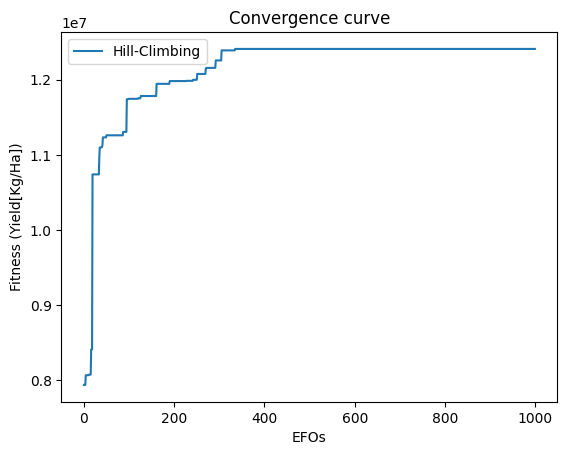

In [ ]:
print("Best Fitnes: ", best_fitness_hc)
plot_convergence_curve(best_fitness_history_hc, hc1)

## 2. Optimización SA

In [ ]:
# Optimizacion paracticas de manejo del cultivo para   - SA (Simuling Aneling)
# =========================================================================================================
np.random.seed(5)
max_efos = 1000
bandwidth = 2
presupuesto = 4000000
precioVenta = 2500
f2 = CLR(modelo_clasificacion, lista_models)
fc2 = CostVariables(CostosUnitariosVarOpimizar, variablesOptimizar)
SA1 = SA(max_efos,bandwidth)
best_fitness_history_sa, best_fitness_sa, best_SA = SA1.evolve(variablesOptimizar, f2,fc2, df_opti, columns_train_models,cf,presupuesto,precioVenta)

(1, 114)


<ipython-input-3-6e4f6a7a4546>:297: RuntimeWarning: overflow encountered in exp
  prob = np.exp((Qrg-Qsg) / t) # Maximizando (Ganancias)
<ipython-input-3-6e4f6a7a4546>:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.57' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff.loc[:,var_select]= list_vac
<ipython-input-3-6e4f6a7a4546>:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.95' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff.loc[:,var_select]= list_vac
<ipython-input-3-6e4f6a7a4546>:208: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '1.92' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff.loc[:,var_select]= list_vac
<ipython-input-3-6e4

In [ ]:
best_fitness_sa

np.float64(12171230.76)

In [ ]:
print("Cantidad del vector history: ", len(best_fitness_history_sa))
best_fitness_history_sa

Cantidad del vector history:  1000


array([ 7937779.22,  7937779.22,  7937779.22,  7937779.22,  7937779.22,
        7937779.22,  8060115.13,  8060115.13,  8060115.13,  8060115.13,
        8065473.46,  8065473.46,  8065473.46,  8065473.46,  8065473.46,
        8065473.46,  8065473.46,  8065473.46,  8065473.46,  8801706.49,
        8801706.49,  8801706.49,  8801706.49,  8801706.49,  8801706.49,
        8801706.49,  8801706.49,  8801706.49,  9440658.77,  9440658.77,
        9440658.77,  9440658.77,  9440658.77,  9440658.77,  9440658.77,
        9440658.77, 10085745.32, 10085745.32, 10085745.32, 10192332.3 ,
       10192332.3 , 10192332.3 , 10192332.3 , 10192332.3 , 10192332.3 ,
       10192332.3 , 10192332.3 , 10192332.3 , 10192332.3 , 10400520.9 ,
       10400520.9 , 10400520.9 , 10400520.9 , 10400520.9 , 10400520.9 ,
       11471057.88, 11471057.88, 11471057.88, 11471057.88, 11471057.88,
       11471057.88, 11471057.88, 11471057.88, 11471057.88, 11471057.88,
       11471057.88, 11471057.88, 11471057.88, 11471057.88, 11471

In [ ]:
best_SA[variablesOptimizar]

,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,...,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor
80,3,0,0,0,0,2,0,0,0,0,...,0,1.17,7.16,101.4,1.3,3.13,4.62,1.9,3.36,1.37


Best Fitnes:  12171230.76


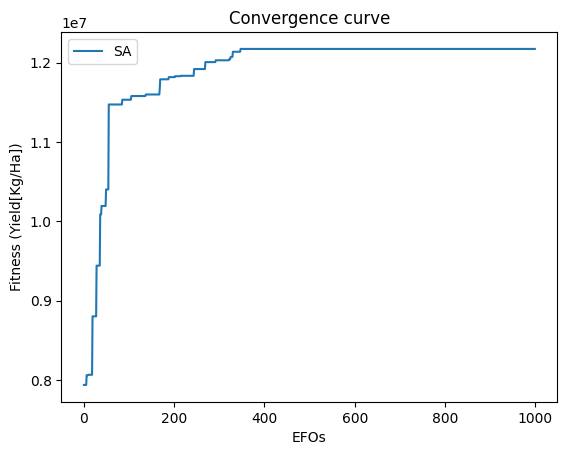

In [ ]:
print("Best Fitnes: ", best_fitness_sa)
plot_convergence_curve(best_fitness_history_sa, SA1)

## 3. Optimizacion Algortimo de Lobo Gris

In [73]:
'''
 Definición de clases algortimo de Lobo Gris (GWO)
'''

class SolutionWolf():
  def __init__(self, variablesOptimizar, f,f_cost, reg_opt, col_train_model,cf,pop_size, presupuesto, precio_venta):
    self.variablesOptimizar = variablesOptimizar
    self.cf = cf
    self.function = f
    self.f_cost = f_cost
    self.fitness = 0
    self.reg_opt = reg_opt
    self.col_train_model = col_train_model
    self.pop_size = pop_size
    self.presupuesto= presupuesto
    self.precio_venta = precio_venta



  def initialization(self):
    df_opt= self.reg_opt.copy()
    df_opt_dm = pd.get_dummies(df_opt, columns=self.cf,dtype=np.int64)
    df_opt_dm_m = df_opt_dm.reindex(columns=self.col_train_model, fill_value=0)
    self.fitness= self.function.evaluate(df_opt_dm_m)

    self.costo = self.f_cost.evaluate(df_opt)
    # Aqui se define el presupuesto asociado para mi LOTE.
    if self.costo < self.presupuesto:
      self.Ganancia = (self.fitness * self.precio_venta) - self.costo
    else:
      self.Ganancia = float('-inf')
    return self.fitness, df_opt, df_opt_dm_m,np.round(self.Ganancia,2), np.round(self.costo,2)


  def generateNewWolf(self, reg_opt):
      df_opt= reg_opt.copy()
      # Rangos Varaibles Categoricas.
      #===============================================================
      TIPO_SIEMBRA = ["Manual","Mecanizado"]
      SEM_TRATADAS =[1,0]
      MATERIAL_GENETICO = ['Otro', 'P3966 (Pioneer)', 'P4082 (Pioneer)', 'DK 234', 'PAC 105',
            'NK254 (Syngenta)', 'PIONEER 30F35', 'PIONEER 30F35 HRR',
            'DK 234 YGRR', 'Impacto (Syngenta)', 'ICA V 305',
            'PIONEER 30F35 H', 'ADV 9339 (Syngenta)', 'DK7088',
            'PIONEER 30F32', 'CORPOICA V 114', 'Sinko (Syngenta)',
            'ADV 9293 (Syngenta)', 'DK 1596', 'Status (Syngenta)',
            'Cerato (Syngenta)', 'ICA V 156', 'ICA V 109', 'PIONEER 30F32HW',
            'FNC 3056', 'FNC 114', 'DK 1040']
      METODO_COSECHA = ['Manual', 'Mecanizada']
      #===============================================================
      # Actualizacion Registro a Optimizar.
      df_opt.loc[:,self.variablesOptimizar]= [
                                              np.random.randint(0,4),
                                              np.random.randint(0,2),
                                              np.random.randint(0,2),
                                              np.random.randint(0,2),     # Final 3 Linea
                                              np.random.randint(0,2),
                                              np.random.randint(0,3),
                                              np.random.randint(0,4),
                                              np.random.randint(0,5),
                                              np.random.randint(0,3),
                                              np.random.randint(0,2),
                                              np.random.randint(0,3),
                                              np.random.randint(0,10),
                                              np.random.randint(0,3),
                                              round(np.random.uniform(0,115),2),
                                              round(np.random.uniform(0,82.5),2),
                                              round(np.random.uniform(0,276),2),
                                              np.random.randint(0,25),
                                              round(np.random.uniform(0,40),2),
                                              round(np.random.uniform(0,47.5),2),
                                              np.random.randint(0,31),
                                              round(np.random.uniform(0,75),2),
                                              round(np.random.uniform(0,180),2)]


      #Proceso Dumificacion
      nrd = pd.get_dummies(df_opt, columns=self.cf,dtype=np.int64)
      nrd = nrd.reindex(columns=self.col_train_model, fill_value=0)
      self.fitness= self.function.evaluate(nrd)

      # Aqui incluimos la Ganancia.
      # Calculo de la ganacia y costo asociado al registro
      self.costo = self.f_cost.evaluate(df_opt)
      # Aqui se define el presupuesto asociado para mi LOTE.
      if self.costo < self.presupuesto:
        self.Ganancia = (self.fitness * self.precio_venta) - self.costo
      else:
        self.Ganancia = float('-inf')

      return self.fitness, df_opt, nrd, np.round(self.Ganancia,2), np.round(self.costo,2)

  def generatePopulationWolfs(self,reg_opt):
    # Generamos las Poblacion de lobos
    lista_population = []
    for i in range(self.pop_size):
      fit,d,d_d,g,c= self.generateNewWolf(reg_opt)             # C/d elemento de la población esta conformado por una ganancia y registro
      lista_population.append((g,d))

    return lista_population


  '''
     Función para el cambio de variables categoricas
  '''

  def changeCategoricalFeatures(self,lista_var_cat,dff):
    list_vac = []
    for variable in lista_var_cat:
        match variable:
            case 'ContEnfQui_Emer_Flor':
              r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContEnfQui_Flor_Cose':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContMalMec_Siem_Emer':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContMalMec_Emer_Flor':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContMalMec_Flor_Cose':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContMalQui_Antes_Siem':
              r = np.random.choice([x for x in range(3) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContMalQui_Siem_Emer':
              r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContMalQui_Emer_Flor':
              r = np.random.choice([x for x in range(5) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContMalQui_Flor_Cose':
              r = np.random.choice([x for x in range(2) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContPlaQui_Antes_Siem':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'ContPlaQui_Siem_Emer':
              r = np.random.choice([x for x in range(3) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContPlaQui_Emer_Flor':
              r = np.random.choice([x for x in range(10) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'ContPlaQui_Flor_Cose':
              r = np.random.choice([x for x in range(3) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'FerOrg_Emer_Flor':
              list_vac.append(abs(dff[variable].values[0]-1))

            case 'FerQui_Antes_Siem':
              r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'FerQui_Siem_Emer':
              r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)

            case 'FerQui_Emer_Flor':
              r = np.random.choice([x for x in range(8) if x != dff[variable].values[0]] , 1)[0]
              list_vac.append(r)


            case _:
                print("Error")

    # Actualizacion Registro a Optimizar
    # =====================================================================================
    #print("Valores Remplazar: ", list_vac)
    return list_vac



  '''
     Función para el cambio de variables categoricas (incluyendo factor de exploración y Explotación)
     de acuerdo a la probabilidad definida
  '''

  def changeCategoricalFeaturesv1(self,lista_var_cat,dff, alpha_pos, beta_pos, delta_pos):
    # Definición probabilidad Local
    p_local = 0.8
    aleatorio = np.random.random()
    #print(aleatorio)

    if aleatorio < p_local:
      #print("Asignación Teniedo en cuenta los lobos")
      list_vac = []
      for variable in lista_var_cat:
          match variable:
              case 'ContEnfQui_Emer_Flor':
                l = [alpha_pos['ContEnfQui_Emer_Flor'].values[0], beta_pos['ContEnfQui_Emer_Flor'].values[0],  delta_pos['ContEnfQui_Emer_Flor'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContEnfQui_Flor_Cose':
                l = [alpha_pos['ContEnfQui_Flor_Cose'].values[0], beta_pos['ContEnfQui_Flor_Cose'].values[0],  delta_pos['ContEnfQui_Flor_Cose'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContMalMec_Siem_Emer':
                l = [alpha_pos['ContMalMec_Siem_Emer'].values[0], beta_pos['ContMalMec_Siem_Emer'].values[0],  delta_pos['ContMalMec_Siem_Emer'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContMalMec_Emer_Flor':
                l = [alpha_pos['ContMalMec_Emer_Flor'].values[0], beta_pos['ContMalMec_Emer_Flor'].values[0],  delta_pos['ContMalMec_Emer_Flor'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContMalMec_Flor_Cose':
                l = [alpha_pos['ContMalMec_Flor_Cose'].values[0], beta_pos['ContMalMec_Flor_Cose'].values[0],  delta_pos['ContMalMec_Flor_Cose'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContMalQui_Antes_Siem':
                l = [alpha_pos['ContMalQui_Antes_Siem'].values[0], beta_pos['ContMalQui_Antes_Siem'].values[0],  delta_pos['ContMalQui_Antes_Siem'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContMalQui_Siem_Emer':
                l = [alpha_pos['ContMalQui_Siem_Emer'].values[0], beta_pos['ContMalQui_Siem_Emer'].values[0],  delta_pos['ContMalQui_Siem_Emer'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContMalQui_Emer_Flor':
                l = [alpha_pos['ContMalQui_Emer_Flor'].values[0], beta_pos['ContMalQui_Emer_Flor'].values[0],  delta_pos['ContMalQui_Emer_Flor'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContMalQui_Flor_Cose':
                l = [alpha_pos['ContMalQui_Flor_Cose'].values[0], beta_pos['ContMalQui_Flor_Cose'].values[0],  delta_pos['ContMalQui_Flor_Cose'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContPlaQui_Antes_Siem':
                l = [alpha_pos['ContPlaQui_Antes_Siem'].values[0], beta_pos['ContPlaQui_Antes_Siem'].values[0],  delta_pos['ContPlaQui_Antes_Siem'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContPlaQui_Siem_Emer':
                l = [alpha_pos['ContPlaQui_Siem_Emer'].values[0], beta_pos['ContPlaQui_Siem_Emer'].values[0],  delta_pos['ContPlaQui_Siem_Emer'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContPlaQui_Emer_Flor':
                l = [alpha_pos['ContPlaQui_Emer_Flor'].values[0], beta_pos['ContPlaQui_Emer_Flor'].values[0],  delta_pos['ContPlaQui_Emer_Flor'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)

              case 'ContPlaQui_Flor_Cose':
                l = [alpha_pos['ContPlaQui_Flor_Cose'].values[0], beta_pos['ContPlaQui_Flor_Cose'].values[0],  delta_pos['ContPlaQui_Flor_Cose'].values[0]]
                r = np.random.choice(l , 1)[0]
                list_vac.append(r)


              case _:
                  print("Error")


    else:
      #print("Asignación sin teniedo en cuenta los lobos")
      list_vac = []
      for variable in lista_var_cat:
          match variable:
              case 'ContEnfQui_Emer_Flor':
                r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'ContEnfQui_Flor_Cose':
                list_vac.append(abs(dff[variable].values[0]-1))

              case 'ContMalMec_Siem_Emer':
                list_vac.append(abs(dff[variable].values[0]-1))

              case 'ContMalMec_Emer_Flor':
                list_vac.append(abs(dff[variable].values[0]-1))

              case 'ContMalMec_Flor_Cose':
                list_vac.append(abs(dff[variable].values[0]-1))

              case 'ContMalQui_Antes_Siem':
                r = np.random.choice([x for x in range(3) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'ContMalQui_Siem_Emer':
                r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'ContMalQui_Emer_Flor':
                r = np.random.choice([x for x in range(5) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'ContMalQui_Flor_Cose':
                r = np.random.choice([x for x in range(2) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'ContPlaQui_Antes_Siem':
                list_vac.append(abs(dff[variable].values[0]-1))

              case 'ContPlaQui_Siem_Emer':
                r = np.random.choice([x for x in range(3) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'ContPlaQui_Emer_Flor':
                r = np.random.choice([x for x in range(10) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'ContPlaQui_Flor_Cose':
                r = np.random.choice([x for x in range(3) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'FerOrg_Emer_Flor':
                list_vac.append(abs(dff[variable].values[0]-1))

              case 'FerQui_Antes_Siem':
                r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'FerQui_Siem_Emer':
                r = np.random.choice([x for x in range(4) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)

              case 'FerQui_Emer_Flor':
                r = np.random.choice([x for x in range(8) if x != dff[variable].values[0]] , 1)[0]
                list_vac.append(r)


              case _:
                  print("Error")

      # Actualizacion Registro a Optimizar
      # =====================================================================================
      #print("Valores Remplazar: ", list_vac)
    return list_vac


class GWO():
   def __init__(self, pop_size, max_efos):
        self.pop_size = pop_size
        self.max_efos = max_efos

   def envolve(self,variablesOptimizar, f1,fc, df_opti, columns_train_models,cf,pop_size,presupuesto,precio_venta):
    no_improvement_count = 0
    best_fitness_history = np.zeros(self.max_efos, float)
    # Generamos las poblacion de lobos
    # Pop (Lista de Tuplas [fitnes, df])
    # ====================================================================
    Sol = SolutionWolf(variablesOptimizar, f1, fc, df_opti, columns_train_models,cf,pop_size,presupuesto,precio_venta)
    pop = Sol.generatePopulationWolfs(df_opti)

    # Ordenamos la poblacion de acuerdo al Fitness
    # ===================================================================
    pop_ord = sorted(pop, key=lambda x: x[0], reverse=True)

    for k in range(self.max_efos):
      print("------------EFO--------- ", k)

      # Definicion de la jerarquia de Lobos (Alfa, Beta, Delta)
      #=================================================================
      alpha_fitnes, beta_fitnes, delta_fitnes = pop_ord[0][0], pop_ord[1][0], pop_ord[2][0]
      alpha_pos, beta_pos, delta_pos = pop_ord[0][1], pop_ord[1][1], pop_ord[2][1]
      print(f"Los fitnes asociados son alpha: {alpha_fitnes}, beta: {beta_fitnes}, delta: {delta_fitnes}")

      # Proceso de casa y busqueda de Lobos
      # =================================================================
      a = 2*(1 - k/EFOS)
      A1, A2, A3 = a * (2 * np.random.random() - 1), a * (2 * np.random.random() - 1), a * (2 * np.random.random() - 1)
      C1, C2, C3 = 2 * np.random.random(), 2*np.random.random(), 2*np.random.random()

      # Definicion de variables continuas y categoricas
      #=====================================================================
      varContinuas = ['TotN_Antes_Siem','TotN_Siem_Emer','TotN_Emer_Flor','TotP_Antes_Siem','TotP_Siem_Emer','TotP_Emer_Flor','TotK_Antes_Siem','TotK_Siem_Emer','TotK_Emer_Flor']
      varCategoricas = ['ContEnfQui_Emer_Flor','ContEnfQui_Flor_Cose','ContMalMec_Siem_Emer','ContMalMec_Emer_Flor','ContMalMec_Flor_Cose',
                        'ContMalQui_Antes_Siem','ContMalQui_Siem_Emer','ContMalQui_Emer_Flor','ContMalQui_Flor_Cose','ContPlaQui_Antes_Siem',
                        'ContPlaQui_Siem_Emer','ContPlaQui_Emer_Flor','ContPlaQui_Flor_Cose']

      #Limite | Tupas con los valore minimos y maximos
      # ========================================================================================
      limites_continuas = [(0,105),(0,82.5),(0,276),(0,24),(0,40),(0,47.5),(0,30),(0,75),(0,180)]

      # Proceso con variables continuas.
      # ======================================================================================
      for z in range(self.pop_size):
        #print(f"Elemento Poblacion {z}")
        X1 = [0 for i in range(len(varContinuas))]
        X2 = [0 for i in range(len(varContinuas))]
        X3 = [0 for i in range(len(varContinuas))]
        new_values_continious = [0 for i in range(len(varContinuas))]

        for i in range(len(varContinuas)):
          X1[i] = alpha_pos[varContinuas[i]].values[0] - A1 * abs(C1 - alpha_pos[varContinuas[i]].values[0] -pop_ord[z][1][varContinuas[i]].values[0])
          X2[i] = beta_pos[varContinuas[i]].values[0] - A2 * abs(C2 - beta_pos[varContinuas[i]].values[0] -pop_ord[z][1][varContinuas[i]].values[0])
          X3[i] = delta_pos[varContinuas[i]].values[0] - A3 * abs(C3 - delta_pos[varContinuas[i]].values[0] -pop_ord[z][1][varContinuas[i]].values[0])
          x_nuevo = (X1[i] + X2[i] + X3[i])/3


          new_values_continious[i] = round(np.clip(x_nuevo,limites_continuas[i][0],limites_continuas[i][1]),2)

        dff_mut = df_opti.copy()
        dff_mut.loc[:,varContinuas]= new_values_continious

        # Proceso con las variables categoricas (Valor diferente al actual)
        # =====================================================================================
        #var_cat= Sol.changeCategoricalFeatures(varCategoricas,dff_mut)
        var_cat= Sol.changeCategoricalFeaturesv1(varCategoricas,dff_mut,alpha_pos,beta_pos,delta_pos)
        dff_mut.loc[:,varCategoricas]= var_cat


        # Calculo Ganancia nueva solución
        a_fit,a_rg,a_reg_dm,a_gan,a_cost = SolutionWolf(variablesOptimizar, f1, fc, dff_mut,columns_train_models,cf,pop_size,presupuesto,precio_venta).initialization()
        #print("Fitenes (Ganancia) Nueva Solucion: ", a_gan)
        #print("Costo Nueva Solucion: ", a_cot)


        if a_gan > pop_ord[z][0]:
          #print("Mejor solucion Actualizada")
          pop_ord[z] = (a_gan,dff_mut)





      # Ordeno la Poblacion de los lobos para la proxima iteracion
      # =========================================================================================
      pop_ord = sorted(pop_ord, key=lambda x: x[0], reverse=True)
      best_fitness_history[k] = alpha_fitnes

      #print(f"==================== Iteracion {k} tiene un Alfa Fitenes de {alpha_fitnes}")


      if k > 0 and alpha_fitnes == best_fitness_history[k-1]:
        no_improvement_count += 1
        if no_improvement_count >= 50:
          best_fitness_history[k:] = alpha_fitnes
          break
      else:
        no_improvement_count = 0



    return best_fitness_history, alpha_fitnes,alpha_pos, beta_pos, delta_pos

   def __str__(self):
     result = "GWO"
     return result

In [74]:
# Proceso de optimización de practicas de manejo medinate  - Algortimo GWO
# ================================================================================================================
np.random.seed(6)
EFOS=1000
PopZize=20
Presupuesto = 4000000
precioVenta = 2500
f3 = CLR(modelo_clasificacion, lista_models)
fc3 = CostVariables(CostosUnitariosVarOpimizar, variablesOptimizar)
# Instanaciamos las clase lobo
gwo = GWO(PopZize,EFOS)
best_fitness_history_grey_wolfs, fitness_alfa,alpha_pos,beta_pos, delta_pos = gwo.envolve(variablesOptimizar,f3,fc3,df_opti,columns_train_models,cf,PopZize, Presupuesto, precioVenta)



------------EFO---------  0
Los fitnes asociados son alpha: 20197226.65, beta: 18733608.42, delta: 18670127.32


<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '16.76' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '11.95' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '16.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is d

------------EFO---------  1
Los fitnes asociados son alpha: 20560045.49, beta: 20513176.46, delta: 20197226.65
------------EFO---------  2
Los fitnes asociados son alpha: 20560045.49, beta: 20513176.46, delta: 20197226.65


<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '26.49' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '25.06' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '25.06' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is d

------------EFO---------  3
Los fitnes asociados son alpha: 23477518.68, beta: 23122329.89, delta: 23069773.28
------------EFO---------  4
Los fitnes asociados son alpha: 23477518.68, beta: 23122329.89, delta: 23069773.28


...

------------EFO---------  48
Los fitnes asociados son alpha: 23477518.68, beta: 23253339.36, delta: 23253110.84


<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '14.16' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '17.68' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '14.16' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is d

------------EFO---------  49
Los fitnes asociados son alpha: 23477518.68, beta: 23253339.36, delta: 23253110.84
------------EFO---------  50
Los fitnes asociados son alpha: 23477518.68, beta: 23253339.36, delta: 23253110.84
------------EFO---------  51
Los fitnes asociados son alpha: 23477518.68, beta: 23253339.36, delta: 23253110.84


<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '22.81' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '28.48' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '22.81' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  dff_mut.loc[:,varContinuas]= new_values_continious
<ipython-input-73-73a6ae63ba78>:409: FutureWarning: Setting an item of incompatible dtype is d

------------EFO---------  52
Los fitnes asociados son alpha: 23477518.68, beta: 23253339.36, delta: 23253110.84
------------EFO---------  53
Los fitnes asociados son alpha: 23477518.68, beta: 23253339.36, delta: 23253110.84


In [75]:
# Historico del Fitness
best_fitness_history_grey_wolfs

array([20197226.65, 20560045.49, 20560045.49, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477518.68,
       23477518.68, 23477518.68, 23477518.68, 23477518.68, 23477

Best Fitnes:  23477518.68


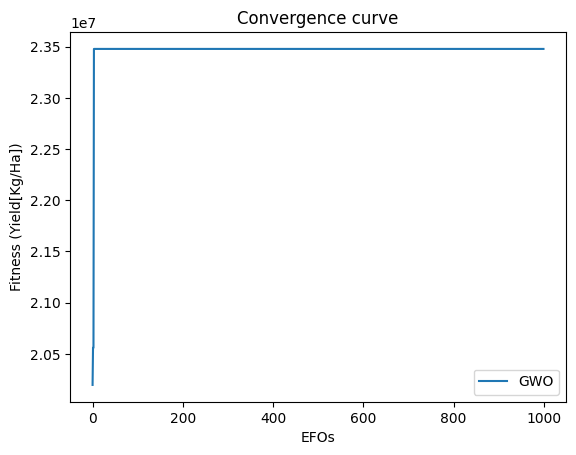

In [76]:
print("Best Fitnes: ", fitness_alfa)
plot_convergence_curve(best_fitness_history_grey_wolfs, gwo)

In [77]:
# Variables sin optimizar
df_opti[variablesOptimizar]

,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor
84,0,1,0,0,0,2,0,2,0,1,0,1,2,0.0,15.0,92.0,0,15.0,0.0,0,15.0,30.0


In [78]:
# Variables Optimizadas
alpha_pos[variablesOptimizar]

,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,ContMalMec_Flor_Cose,ContMalQui_Antes_Siem,ContMalQui_Siem_Emer,ContMalQui_Emer_Flor,ContMalQui_Flor_Cose,ContPlaQui_Antes_Siem,ContPlaQui_Siem_Emer,ContPlaQui_Emer_Flor,ContPlaQui_Flor_Cose,TotN_Antes_Siem,TotN_Siem_Emer,TotN_Emer_Flor,TotP_Antes_Siem,TotP_Siem_Emer,TotP_Emer_Flor,TotK_Antes_Siem,TotK_Siem_Emer,TotK_Emer_Flor
84,3,1,0,0,0,0,1,3,0,0,0,0,2,105.0,80.1,276.0,24,31.19,47.5,30,75.0,61.23


In [87]:
'''
 - Calculo del rendimiento asociado al cultivo optimizado
 - En este caso se suministra la solución optimizada para el cultivo teniedno en cuenta la mejor solución (alpha)
 - Calculamos el rendimiento, costo y ganancia asociado al cultivo
'''
# (Volvemos a inicializar la solución para obtner los valores requeridos)
# =========================================================
#best_fitness_history_grey_wolfs, fitness_alfa,alpha_pos = gwo.envolve(variablesOptimizar,f3,fc3,df_opti,columns_train_models,cf,PopZize, Presupuesto, precioVenta)
gwo1 = SolutionWolf(variablesOptimizar, f3,fc3, alpha_pos, columns_train_models,cf,PopZize, Presupuesto, precioVenta)
yield_corn, reg , reg_d, gan , costo = gwo1.initialization()

In [88]:
yield_corn

np.float64(10572.595472201676)

In [89]:
gan

np.float64(23477518.68)

In [90]:
costo

np.float64(2953970.0)

In [91]:

'''
 - Calculo del rendimiento asociado al cultivo original
 - Calculamos el rendimiento, costo y ganancia asociado al cultivo
'''
# =========================================================
#best_fitness_history_grey_wolfs, fitness_alfa,alpha_pos = gwo.envolve(variablesOptimizar,f3,fc3,df_opti,columns_train_models,cf,PopZize, Presupuesto, precioVenta)
gwo1 = SolutionWolf(variablesOptimizar, f3,fc3, df_opti, columns_train_models,cf,PopZize, Presupuesto, precioVenta)
yield_corn, reg , reg_d, gan , costo = gwo1.initialization()

In [92]:
yield_corn

np.float64(7405.823076829209)

In [93]:
gan

np.float64(17274157.69)

In [86]:
costo

np.float64(1240400.0)

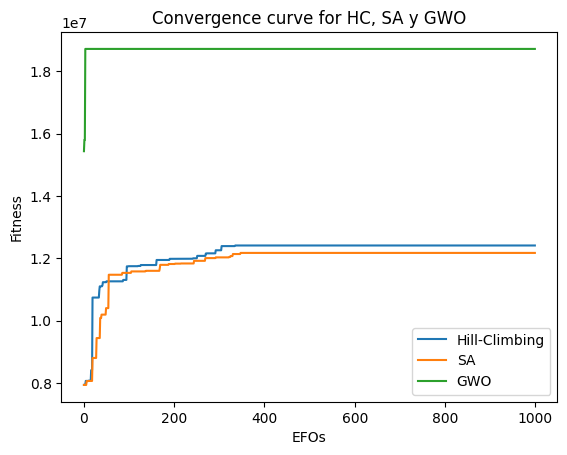

In [ ]:
# Se Pintan todas las curvas en un solo Grafico - Para verificar el desempeño para un evento en particular
# =========================================================================================================
algs =[]
algs.append(str(hc1))
algs.append(str(SA1))
algs.append(str(gwo))


curves =[]
curves.append(best_fitness_history_hc)
curves.append(best_fitness_history_sa)
curves.append(best_fitness_history_grey_wolfs)

# Graficamos las curvas en una Sola Grafica para un unico Archivo
plot_convergence_curve_comparison(curves, algs)
